# Convolution and Transpose Convolution

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


---
## 1 — Convolution as a Toeplitz Matrix (1D, stride 1)

A 1D valid convolution with kernel **k** (length K) maps input **x** (length N) to output **y** (length N−K+1).  
Each output element is a dot product of **k** with a shifted window of **x**:

$$y_i = \sum_{j=0}^{K-1} k_j\, x_{i+j}$$

Written as a matrix for N=5, K=3:

$$\begin{pmatrix} y_0 \\ y_1 \\ y_2 \end{pmatrix}
= \underbrace{\begin{pmatrix}
k_0 & k_1 & k_2 &  0  &  0  \\
 0  & k_0 & k_1 & k_2 &  0  \\
 0  &  0  & k_0 & k_1 & k_2
\end{pmatrix}}_{\mathbf{W}\;(3\times5)}
\begin{pmatrix} x_0 \\ x_1 \\ x_2 \\ x_3 \\ x_4 \end{pmatrix}$$

The kernel appears on each diagonal — a **Toeplitz** structure.


W:
[[1. 2. 1. 0. 0.]
 [0. 1. 2. 1. 0.]
 [0. 0. 1. 2. 1.]]

W @ x = [5. 3. 5.]
nn.Conv1d(x) = [5. 3. 5.]


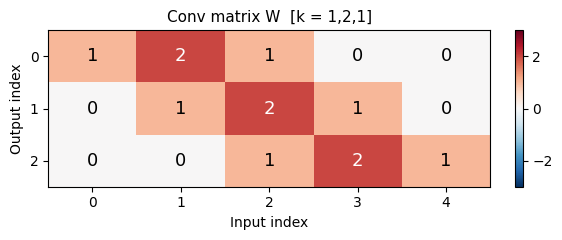

In [2]:
k = np.array([1., 2., 1.]) # kernel
N_IN = 5  # number of input dimensions
K = len(k) # length of the kernel
N_OUT = N_IN - K + 1 # number of output dimensions 3

# generation of the Toeplitz matrix
W = np.zeros((N_OUT, N_IN))
for i in range(N_OUT):
    W[i, i:i+K] = k

x = np.array([3., 1., 0., 2., 1.]) # input 
y_mat   = W @ x # convolution applied to the input

conv1d  = nn.Conv1d(1, 1, K, bias=False) # torch 1d convolution (1 input kernel, 1 output kernel, filter size K, no bias)
conv1d.weight.data = torch.tensor(k).view(1, 1, -1).float() 
y_torch = conv1d(torch.tensor(x).view(1, 1, -1).float()).squeeze().detach().numpy()

# comparing results
print(f"W:\n{W}")
print(f"\nW @ x = {y_mat}")
print(f"nn.Conv1d(x) = {y_torch}")

# printing the Toeplitz matrix
fig, ax = plt.subplots(figsize=(6, 2.5))
im = ax.imshow(W, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
for i in range(N_OUT):
    for j in range(N_IN):
        ax.text(j, i, f"{W[i,j]:.0f}", ha="center", va="center", fontsize=13,
                color="white" if abs(W[i,j]) > 1 else "black")
ax.set_xlabel("Input index"); ax.set_ylabel("Output index")
ax.set_title("Conv matrix W  [k = 1,2,1]", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout(); plt.show()


---
## 2 — Transpose Convolution = Wᵀ (1D, stride 1)

Transposing **W** flips the spatial direction:

- **W** : (N_out × N_in) — contracts 5 inputs → 3 outputs
- **Wᵀ** : (N_in × N_out) — **expands** 3 inputs → 5 outputs


Feeding a unit vector **e_i** into Wᵀ produces the kernel **k** stamped at offset i — the impulse response.


W^T:
[[1. 0. 0.]
 [2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]
 [0. 0. 1.]]

Impulse responses (unit input at position i -> output of Wᵀ):
 e_0 → [1. 2. 1. 0. 0.]   (kernel stamped at offset 0)
 e_1 → [0. 1. 2. 1. 0.]   (kernel stamped at offset 1)
 e_2 → [0. 0. 1. 2. 1.]   (kernel stamped at offset 2)

y_in = [2. 0. 1.]
Wᵀ @ y_in = [2. 4. 3. 2. 1.]
nn.ConvTranspose1d = [2. 4. 3. 2. 1.]


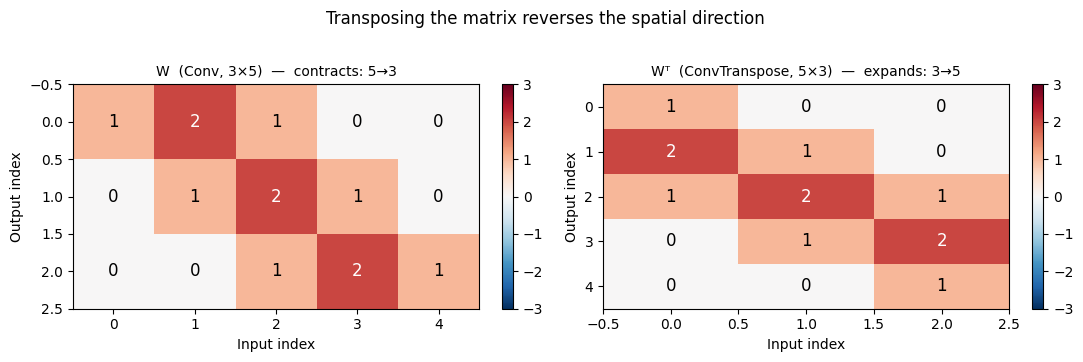

In [3]:
# Let's take the transpose of the previous convolutional map
W_T = W.T # (5 × 3)

print("W^T:")
print(W_T)
# here we extract and inspect the columns of W^T
print("\nImpulse responses (unit input at position i -> output of Wᵀ):")
for i in range(N_OUT):
    e = np.zeros(N_OUT); e[i] = 1.
    print(f" e_{i} → {W_T @ e}   (kernel stamped at offset {i})")

# let's apply manually the transpose convolution to some input y_in
y_in  = np.array([2., 0., 1.])
x_mat = W_T @ y_in

# let's use pytorch to do the same
ct1d  = nn.ConvTranspose1d(1, 1, K, bias=False)
ct1d.weight.data = torch.tensor(k).view(1, 1, -1).float()
x_torch = ct1d(torch.tensor(y_in).view(1, 1, -1).float()).squeeze().detach().numpy()

print(f"\ny_in = {y_in}")
print(f"Wᵀ @ y_in = {x_mat}")
print(f"nn.ConvTranspose1d = {x_torch}")

# now let's plot the matrices W and W^T
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, mat, title in [
    (axes[0], W,   "W  (Conv, 3×5)  —  contracts: 5→3"),
    (axes[1], W_T, "Wᵀ  (ConvTranspose, 5×3)  —  expands: 3→5"),
]:
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-3, vmax=3, aspect="auto")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center", fontsize=12,
                    color="white" if abs(mat[i,j]) > 1 else "black")
    ax.set_xlabel("Input index"); ax.set_ylabel("Output index")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.06)
plt.suptitle("Transposing the matrix reverses the spatial direction", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

---
## 3 — Stride (1D)

With stride s, the convolution matrix keeps only every s-th row of the full stride-1 matrix:

$$\text{output length} = \left\lfloor\frac{N-K}{s}\right\rfloor + 1$$

The transpose of a stride-s convolution matrix is a ConvTranspose with the same stride s:

$$\text{output length} = s(N-1) + K$$

In [4]:
stride = 2
N_IN_S = 5                        
N_OUT_S = (N_IN_S - K) // stride + 1  # = 2

# let's build the convolutional map as usual (now with stride = 2)
W_s = np.zeros((N_OUT_S, N_IN_S))
for i in range(N_OUT_S):
    W_s[i, i*stride : i*stride + K] = k

print(f"Stride-2 conv matrix W_s  ({N_OUT_S}×{N_IN_S}):\n{W_s}")
print(f"\nWsᵀ  ({N_IN_S}×{N_OUT_S}):\n{W_s.T}")

# let's compare pytorch Tconv with the manual implementation 
y_in = np.array([3., 1.]) # input
n = len(y_in) 
ct_s = nn.ConvTranspose1d(1, 1, K, stride=stride, bias=False)
ct_s.weight.data = torch.tensor(k).view(1, 1, -1).float()
y_torch_s = ct_s(torch.tensor(y_in).view(1, 1, -1).float()).squeeze().detach().numpy()

print(f"\nInput:            {y_in}  (length {len(y_in)})")
print(f"Wsᵀ @ y_in:       {W_s.T @ y_in}")
print(f"nn.ConvTranspose: {y_torch_s}")

Stride-2 conv matrix W_s  (2×5):
[[1. 2. 1. 0. 0.]
 [0. 0. 1. 2. 1.]]

Wsᵀ  (5×2):
[[1. 0.]
 [2. 0.]
 [1. 1.]
 [0. 2.]
 [0. 1.]]

Input:            [3. 1.]  (length 2)
Wsᵀ @ y_in:       [3. 6. 4. 2. 1.]
nn.ConvTranspose: [3. 6. 4. 2. 1.]


---
## 4 — Extension to 2D

In 2D, a convolution with a K×K kernel applied to an H×W input (stride 1, no padding) is still a linear map.  
Flattening input and output to 1D vectors, the operation is represented by a matrix **M** of shape (H_out·W_out × H·W).

The Conv2d and ConvTranspose2d matrices are exact transposes of each other — same kernel, same stride.  
We can verify this directly by constructing **M** and **Mᵀ** column-by-column using unit impulses.


Conv2d matrix M:          (9, 25)
ConvTranspose2d matrix:   (25, 9)
Max |M_T - M.T| = 0.00e+00


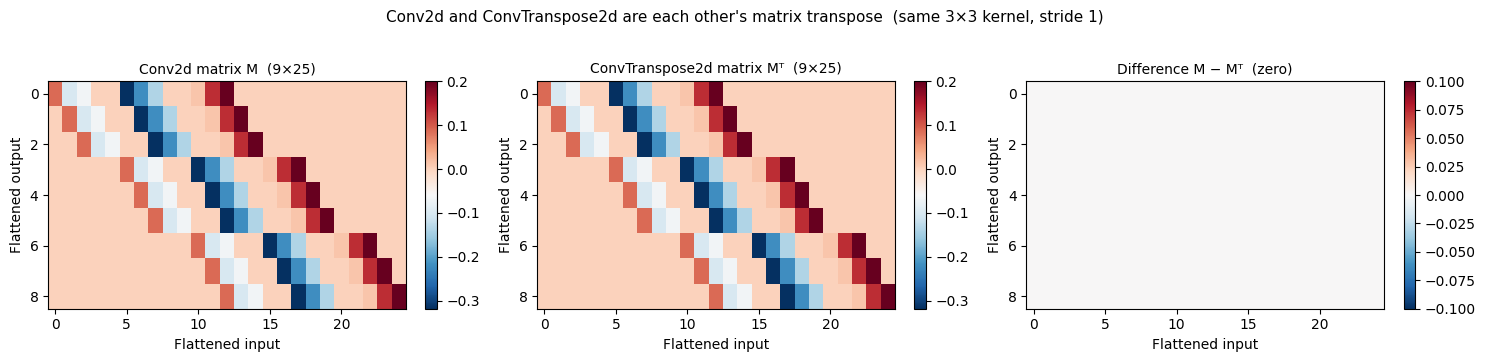

In [5]:
H = W = 5;  K2 = 3
H_o = W_o = H - K2 + 1 # = 3
n_in  = H * W # 25
n_out = H_o * W_o # 9

conv2d  = nn.Conv2d(1, 1, K2, stride=1, padding=0, bias=False)
convT2d = nn.ConvTranspose2d(1, 1, K2, stride=1, padding=0, bias=False)
convT2d.weight.data = conv2d.weight.data    # same kernel

# Build M (n_out × n_in) by feeding unit vectors into Conv2d (we essentially extracting the columns of M one by one)
M = torch.zeros(n_out, n_in)
for i in range(n_in):
    e = torch.zeros(1, 1, H, W); e.view(-1)[i] = 1.
    M[:, i] = conv2d(e).view(-1).detach()

# Build M_T (n_in × n_out) by feeding unit vectors into ConvTranspose2d
M_T = torch.zeros(n_in, n_out)
for i in range(n_out):
    e = torch.zeros(1, 1, H_o, W_o); e.view(-1)[i] = 1.
    M_T[:, i] = convT2d(e).view(-1).detach()

print(f"Conv2d matrix M:          {tuple(M.shape)}")
print(f"ConvTranspose2d matrix:   {tuple(M_T.shape)}")
print(f"Max |M_T - M.T| = {(M_T - M.T).abs().max():.2e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, mat, title in [
    (axes[0], M.numpy(),            "Conv2d matrix M  (9×25)"),
    (axes[1], M_T.T.numpy(),        "ConvTranspose2d matrix Mᵀ  (9×25)"),
    (axes[2], (M - M_T.T).numpy(), "Difference M − Mᵀ  (zero)"),
]:
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto")
    ax.set_xlabel("Flattened input"); ax.set_ylabel("Flattened output")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.suptitle("Conv2d and ConvTranspose2d are each other's matrix transpose  (same 3×3 kernel, stride 1)",
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


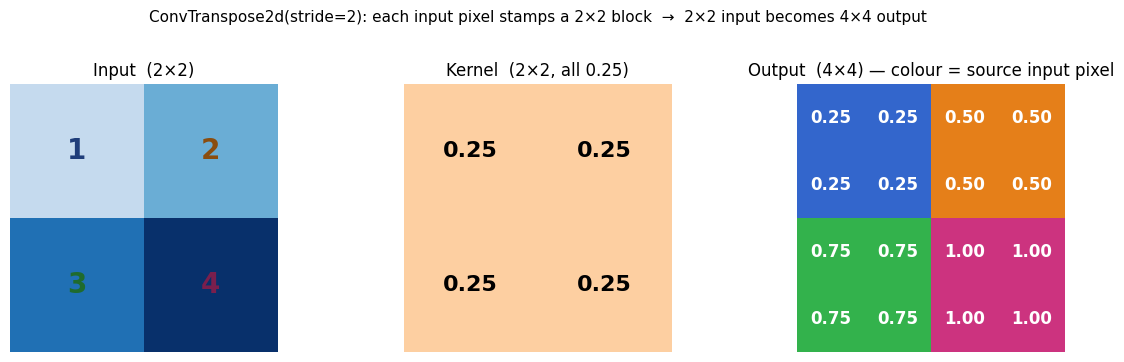

In [6]:
# ConvTranspose2d(stride=2): each input pixel stamps the kernel onto a non-overlapping block
kernel_2d = torch.ones(1, 1, 2, 2) / 4.
feature   = torch.tensor([[[[1., 2.], [3., 4.]]]])

ct2d = nn.ConvTranspose2d(1, 1, 2, stride=2, bias=False)
ct2d.weight.data = kernel_2d
out_np = ct2d(feature)[0, 0].detach().numpy()

COLORS = np.array([[0.20,0.40,0.80],[0.90,0.50,0.10],[0.20,0.70,0.30],[0.80,0.20,0.50]])
color_img = np.ones((4, 4, 3))
for idx, (pi, pj) in enumerate([(0,0),(0,1),(1,0),(1,1)]):
    color_img[pi*2:(pi+1)*2, pj*2:(pj+1)*2] = COLORS[idx]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].imshow(feature[0,0].numpy(), cmap="Blues", vmin=0, vmax=4)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{feature[0,0,i,j]:.0f}", ha="center", va="center",
                     fontsize=20, fontweight="bold", color=COLORS[i*2+j]*0.6)
axes[0].set_title("Input  (2×2)"); axes[0].axis("off")

axes[1].imshow(kernel_2d[0,0].numpy(), cmap="Oranges", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{kernel_2d[0,0,i,j]:.2f}", ha="center", va="center",
                     fontsize=16, fontweight="bold")
axes[1].set_title("Kernel  (2×2, all 0.25)"); axes[1].axis("off")

axes[2].imshow(color_img)
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, f"{out_np[i,j]:.2f}", ha="center", va="center",
                     fontsize=12, fontweight="bold", color="white")
axes[2].set_title("Output  (4×4) — colour = source input pixel"); axes[2].axis("off")

plt.suptitle("ConvTranspose2d(stride=2): each input pixel stamps a 2×2 block  →  2×2 input becomes 4×4 output",
             fontsize=11, y=1.02)
plt.tight_layout(); plt.show()


---
## 5 — The Adjoint Symmetry

For two linear maps $C : X \to Y$ and $C^T : Y \to X$, the **adjoint property** is

$$\langle C(x), v \rangle = \langle x, C^T(v) \rangle \qquad \forall\, x \in X,\; v \in Y.$$

### From adjoint to backward pass

Somewhere above this layer the network has a scalar loss $L$.  
When backprop reaches the layer $y = C(x)$, it already knows $g = \partial L / \partial y$ — **the gradient of $L$ with respect to the layer's output, computed by all the layers above**.  $g$ is a fixed vector at this point; it is not something we differentiate through here.

The chain rule says:

$$\frac{\partial L}{\partial x_i} = \sum_j \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial x_i} = \sum_j g_j\, J_{ji}$$

where $J = \partial y / \partial x$ is the Jacobian. In matrix form: $\nabla_x L = J^\top g$.

For a **linear** layer $y = Wx$, the Jacobian is simply $J = W$, so:

$$\nabla_x L = W^\top g.$$

The right-hand side is exactly what $\operatorname{ConvTranspose}$ computes when applied to $g$ (same kernel $W$, same stride).  
The adjoint property $\langle Wx, g \rangle = \langle x, W^\top g \rangle$ is what guarantees $J^\top = W^\top$.

Applying the same argument when the forward pass is $y = W^\top x$ gives $\nabla_x L = Wg$.

| Forward | $J$ | Backward $\nabla_x L = J^\top g$ |
|---|---|---|
| $y = \operatorname{Conv}(x) = Wx$ | $W$ | $\operatorname{ConvTranspose}(g) = W^\top g$ |
| $y = \operatorname{ConvTranspose}(x) = W^\top x$ | $W^\top$ | $\operatorname{Conv}(g) = Wg$ |

Both cases use the **same kernel and the same stride** — only the spatial direction flips.


In [7]:
torch.manual_seed(7)
# let's create both a conv2d and Transpose conv2d with the same kernel
c_fwd = nn.Conv2d(1, 1, 3, stride=1, padding=0, bias=False)
c_bwd = nn.ConvTranspose2d(1, 1, 3, stride=1, padding=0, bias=False)
c_bwd.weight.data = c_fwd.weight.data    # same kernel W

# ── Step 1: Conv forward — gradient is ConvTranspose ─────────────────────────
# Forward: y = Conv(x) = W x,  Jacobian J = W
# Backward: ∇x L = Jᵀ g = Wᵀ g = ConvTranspose(g)
# We verify with L = y.sum() whose upstream gradient g = dL/dy = ones.

x1 = torch.randn(1, 1, 5, 5, requires_grad=True)
y1 = c_fwd(x1) # 5×5 → 3×3
L1 = y1.sum()
L1.backward() # fills x1.grad

g1 = torch.ones_like(y1)                 # dL/dy = 1 for every output element
grad_manual_1 = c_bwd(g1).detach()       # Wᵀ g, computed by hand

print("Step 1 — Conv forward  →  ConvTranspose backward")
print(f"  upstream grad g = dL/dy     : all ones, shape {tuple(g1.shape)}")
print(f"  x.grad (autograd)  max val  : {x1.grad.abs().max():.6f}")
print(f"  ConvTranspose(g)   max val  : {grad_manual_1.abs().max():.6f}")
print(f"  |difference|                : {(x1.grad - grad_manual_1).abs().max():.2e}")

# ── Step 2: ConvTranspose forward — gradient is Conv ─────────────────────────
# Forward: y = ConvTranspose(x) = Wᵀ x,  Jacobian J = Wᵀ
# Backward: ∇x L = Jᵀ g = W g = Conv(g)
# Same kernel W, same stride — only the spatial direction flips.

ct_fwd = nn.ConvTranspose2d(1, 1, 3, stride=1, padding=0, bias=False)
ct_bwd = nn.Conv2d(1, 1, 3, stride=1, padding=0, bias=False)
ct_bwd.weight.data = ct_fwd.weight.data  # same kernel W

x2 = torch.randn(1, 1, 3, 3, requires_grad=True)
y2 = ct_fwd(x2) # 3×3 → 5×5
g2 = torch.ones_like(y2) # upstream gradient from above
y2.backward(g2) # fills x2.grad

grad_manual_2 = ct_bwd(g2).detach() # W g, computed by hand

print()
print("Step 2 — ConvTranspose forward  →  Conv backward")
print(f"  upstream grad g = dL/dy     : all ones, shape {tuple(g2.shape)}")
print(f"  x.grad (autograd)  max val  : {x2.grad.abs().max():.6f}")
print(f"  Conv(g)            max val  : {grad_manual_2.abs().max():.6f}")
print(f"  |difference|                : {(x2.grad - grad_manual_2).abs().max():.2e}")

Step 1 — Conv forward  →  ConvTranspose backward
  upstream grad g = dL/dy     : all ones, shape (1, 1, 3, 3)
  x.grad (autograd)  max val  : 0.393474
  ConvTranspose(g)   max val  : 0.393474
  |difference|                : 0.00e+00

Step 2 — ConvTranspose forward  →  Conv backward
  upstream grad g = dL/dy     : all ones, shape (1, 1, 5, 5)
  x.grad (autograd)  max val  : 0.461137
  Conv(g)            max val  : 0.461137
  |difference|                : 0.00e+00
